In [1]:
library(mashr)
library(dplyr)
library(tidyr)
library(vroom)

Loading required package: ashr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
cts <- c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')

In [3]:
in.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/'
out.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/mashr/'
dir.create(out.dir)

Warning message in dir.create(out.dir):
“'/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/mashr' already exists”


# Get lead signals

In [4]:
sig.signals <- data.frame()
for (cell in cts) {
    ct.res <- read.table(paste0(in.dir,cell,'.qvalue.cis_qtl.txt.gz'), header=T)
    gc()
    
    ct.res$cell <- cell
    ct.res <- filter(ct.res, qval < 0.05)
    sig.signals <- rbind(sig.signals, ct.res)
    gc()
}

dim(sig.signals)
head(sig.signals)

[1] 391  20

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,ma_count,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,qval,pval_nominal_threshold,cell
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,chr5:178584897-178586396,4700,1.04742,352.619,44.9165,1.99012e-10,rs262042,277,-1221,58,79,0.540698,4.63477e-12,-0.779215,0.0878187,0.00009999,3.14772e-08,2.70541e-03,2.28497e-08,Cholangiocyte
2,chr1:7335429-7336928,3985,1.03458,276.804,44.5579,2.31682e-07,rs10864295,-1717,-3215,49,57,0.331395,1.64772e-08,-0.922434,0.1387070,0.00019998,4.52455e-05,4.85001e-02,2.41319e-07,Hepatocytes
3,chr1:11393161-11394660,2788,1.05387,194.192,44.2264,2.21134e-07,rs55990971,378376,376878,19,21,0.122093,1.37643e-08,1.360070,0.2030310,0.00009999,2.43999e-05,3.05143e-02,4.13540e-07,Hepatocytes
4,chr1:16034219-16035718,3571,1.03907,163.568,43.1928,2.14267e-07,rs6669935,-2030,-3528,54,75,0.563953,8.86827e-09,-0.824313,0.1209110,0.00009999,2.30793e-05,2.93067e-02,4.26525e-07,Hepatocytes
5,chr1:21436617-21438116,4472,1.05599,316.774,44.6411,2.35166e-07,rs66732917,3494,1996,62,84,0.511628,1.72973e-08,0.878225,0.1323200,0.00019998,4.26884e-05,4.69793e-02,2.58608e-07,Hepatocytes
6,chr1:21439342-21440841,4471,1.05464,323.658,44.8551,3.21962e-11,rs1827293,29552,28054,62,83,0.517442,5.22903e-13,0.924423,0.0974943,0.00009999,3.72680e-09,4.39436e-05,2.49931e-07,Hepatocytes


In [5]:
sig.signals$feature_variant <- paste0(sig.signals$phenotype_id, ":", sig.signals$variant_id)

In [6]:
length(unique(sig.signals$feature_variant))

[1] 391

In [7]:
sig.signals <- arrange(sig.signals, qval) %>%
    filter(!duplicated(feature_variant))
sig.signals

phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,⋯,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,qval,pval_nominal_threshold,cell,feature_variant
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
chr7:70957130-70958629,4444,1.034290,276.595000,44.1590,2.67762e-17,rs7778842,13860,12362,51,⋯,0.604651,1.76530e-20,-1.069710,0.0722326,9.999e-05,2.39092e-15,9.86719e-10,2.40835e-07,Hepatocytes,chr7:70957130-70958629:rs7778842
chr19:50903220-50904719,4082,1.052870,455.139000,46.5077,7.88086e-15,rs806024,-3054,-4552,61,⋯,0.476744,1.05049e-16,-1.052280,0.0878374,9.999e-05,8.70066e-13,1.19690e-07,1.74805e-07,Hepatocytes,chr19:50903220-50904719:rs806024
chr8:40917272-40918771,5491,1.051860,269.463000,43.7304,9.36532e-15,rs7002258,-13987,-15485,58,⋯,0.534884,1.37947e-17,-0.986892,0.0782506,9.999e-05,6.17659e-13,1.19690e-07,2.92445e-07,Hepatocytes,chr8:40917272-40918771:rs7002258
chr5:178584897-178586396,4700,1.060180,344.261000,44.4683,2.01880e-14,rs540371,-1031,-2529,61,⋯,0.511628,6.39090e-17,-0.930604,0.0766997,9.999e-05,1.44207e-12,1.48784e-07,2.47423e-07,Hepatocytes,chr5:178584897-178586396:rs540371
chr5:167570418-167571917,3835,1.033550,330.367000,44.9636,2.20702e-14,rs7726117,-191395,-192893,37,⋯,0.244186,1.05254e-16,1.287830,0.1075060,9.999e-05,3.03960e-12,2.50885e-07,2.00188e-07,Hepatocytes,chr5:167570418-167571917:rs7726117
chr11:16603581-16605080,3755,1.045720,170.018000,44.3618,1.06081e-13,rs1837095,-379436,-380934,58,⋯,0.406977,4.24686e-16,1.138620,0.0985487,9.999e-05,5.70521e-12,3.92418e-07,4.37327e-07,Hepatocytes,chr11:16603581-16605080:rs1837095
chr5:167648180-167649679,3788,1.062040,303.403000,44.2149,1.30287e-13,rs13182244,-242524,-244022,37,⋯,0.761628,4.85351e-16,-1.541760,0.1339090,9.999e-05,8.70182e-12,5.13027e-07,2.85622e-07,Hepatocytes,chr5:167648180-167649679:rs13182244
chr14:105161822-105163321,2227,1.052290,118.818000,42.9689,7.99139e-13,rs2280797,-4548,-6046,65,⋯,0.494186,1.70279e-15,1.029420,0.0924297,9.999e-05,2.77687e-11,1.43250e-06,6.65854e-07,Hepatocytes,chr14:105161822-105163321:rs2280797
chr1:152607085-152608584,3827,1.044400,136.448000,42.7818,9.49336e-13,rs67488802,11777,10279,58,⋯,0.581395,1.82780e-15,-1.030470,0.0927001,9.999e-05,4.62372e-11,2.02058e-06,5.38095e-07,Hepatocytes,chr1:152607085-152608584:rs67488802


In [8]:
table(sig.signals$cell)


Cholangiocyte   Hepatocytes       Myeloid 
            1           388             2 

In [10]:
write.table(sig.signals$feature_variant, paste0(in.dir, 'sig.feature.variant.pairs.txt'),
           quote=F, row.names=F, col.names=F, sep='\t')

# Get all signals and random signals, then subset data to sig and random sum stats by cell type

# Read in data

In [14]:
saved_col_names <- colnames(read.table(paste0(in.dir,'Cholangiocyte.cis_qtl_pairs.chr.qvalue.tsv'), sep='\t', nrows = 1,header=T))
saved_col_names

[1] "phenotype_id"           "variant_id"             "start_distance"        
 [4] "end_distance"           "af"                     "ma_samples"            
 [7] "ma_count"               "pval_nominal"           "slope"                 
[10] "slope_se"               "sig.qtl"                "pval_nominal_threshold"

In [15]:
sig.signal.sum.stats <- list()

for (cell in cts) {
    ct.res <- vroom(paste0(in.dir,cell,'.cis_qtl_pairs.sig.mash.tsv'), col_names = saved_col_names)
    gc()
    ct.res$feature_variant <- paste0(ct.res$phenotype_id, ":", ct.res$variant_id)
    sig.signal.sum.stats[[cell]] <- ct.res
    gc()
}

summary(sig.signal.sum.stats)
dim(sig.signal.sum.stats[['Hepatocytes']])
head(sig.signal.sum.stats[['Hepatocytes']])

Rows: 4 Columns: 11
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 113 Columns: 12
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (9): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 177 

              Length Class       Mode
B             12     spec_tbl_df list
Cholangiocyte 13     spec_tbl_df list
Endothelial   12     spec_tbl_df list
Hepatocytes   13     spec_tbl_df list
HSC           12     spec_tbl_df list
Myeloid       13     spec_tbl_df list
NK            12     spec_tbl_df list
T             12     spec_tbl_df list

[1] 391  13

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,sig.qtl,pval_nominal_threshold,feature_variant
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>
chr1:7335429-7336928,rs10864295,-1717,-3215,0.3313954,49,57,1.647720e-08,-0.9224340,0.13870656,TRUE,2.41319e-07,chr1:7335429-7336928:rs10864295
chr1:11393161-11394660,rs55990971,378376,376878,0.1220930,19,21,1.376427e-08,1.3600744,0.20303096,TRUE,4.13540e-07,chr1:11393161-11394660:rs55990971
chr1:16034219-16035718,rs6669935,-2030,-3528,0.5639535,54,75,8.868278e-09,-0.8243131,0.12091061,TRUE,4.26525e-07,chr1:16034219-16035718:rs6669935
chr1:21436617-21438116,rs66732917,3494,1996,0.5116279,62,84,1.729735e-08,0.8782248,0.13231997,TRUE,2.58608e-07,chr1:21436617-21438116:rs66732917
chr1:21439342-21440841,rs1827293,29552,28054,0.5174419,62,83,5.229026e-13,0.9244226,0.09749432,TRUE,2.49931e-07,chr1:21439342-21440841:rs1827293
chr1:21443943-21445442,rs1827293,24951,23453,0.5174419,62,83,6.272220e-09,0.9536407,0.13798855,TRUE,3.03634e-07,chr1:21443943-21445442:rs1827293


In [16]:
rand.signal.sum.stats <- list()

for (cell in cts) {
    ct.res <- vroom(paste0(in.dir,cell,'.cis_qtl_pairs.rand.tsv'), col_names = saved_col_names)
    gc()
    ct.res$feature_variant <- paste0(ct.res$phenotype_id, ":", ct.res$variant_id)
    
    rand.signal.sum.stats[[cell]] <- ct.res
}

summary(rand.signal.sum.stats)
dim(rand.signal.sum.stats[['Hepatocytes']])
head(rand.signal.sum.stats[['Hepatocytes']])

Rows: 518 Columns: 11
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 38187 Columns: 12
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (9): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 

              Length Class       Mode
B             12     spec_tbl_df list
Cholangiocyte 13     spec_tbl_df list
Endothelial   12     spec_tbl_df list
Hepatocytes   13     spec_tbl_df list
HSC           12     spec_tbl_df list
Myeloid       13     spec_tbl_df list
NK            12     spec_tbl_df list
T             12     spec_tbl_df list

[1] 189003     13

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,sig.qtl,pval_nominal_threshold,feature_variant
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>
chr1:505526-507025,rs35745967,868978,867480,0.25000000,38,43,0.5706541,0.13280609,0.2327311,FALSE,8.20086e-07,chr1:505526-507025:rs35745967
chr1:863693-865192,rs7544660,325269,323771,0.06976744,11,12,0.9366386,-0.01993368,0.2495652,FALSE,9.78771e-07,chr1:863693-865192:rs7544660
chr1:903262-904761,rs12029885,286705,285207,0.19767442,29,34,0.9358290,0.01702337,0.2104340,FALSE,9.62955e-07,chr1:903262-904761:rs12029885
chr1:942857-944356,rs915292,917860,916362,0.50581396,64,85,0.4588809,-0.12914410,0.1730834,FALSE,9.53678e-07,chr1:942857-944356:rs915292
chr1:981166-982665,rs6603783,265204,263706,0.13372093,21,23,0.1799222,0.35730425,0.2629295,FALSE,9.23645e-07,chr1:981166-982665:rs6603783
chr1:1001316-1002815,rs12723165,110164,108666,0.15116279,23,26,0.1209793,-0.35157730,0.2230837,FALSE,9.14688e-07,chr1:1001316-1002815:rs12723165


# Create random mash object and estimate correlation

In [17]:
bhat_rand <- bind_rows(rand.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(bhat_rand)
head(bhat_rand)

[1] 200000      8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr1:2848591-2850090:rs4648825,-0.33156220,0.30410510,-0.23598902,0.004170597,-0.2491270,0.14174576,NA,-0.195813430
chr1:2848591-2850090:rs12037485,-0.07560776,0.03830666,0.05013745,-0.021588286,-0.2133032,-0.16908012,NA,-0.147462030
chr1:6248058-6249557:rs11260646,0.06458753,0.04210688,-0.35678533,-0.010173614,-0.1712124,-0.05559033,0.07901631,0.007418496
chr1:6420011-6421510:rs10864279,0.08884251,-0.19052920,0.06059422,-0.212580700,-0.1246293,0.15632851,-0.09846040,-0.326872050
chr1:6439459-6440958:rs1540712,-0.02974801,NA,0.43781576,-0.073057316,-0.2127294,0.01837452,-0.13145994,-0.051402090
chr1:18643211-18644710:rs7536137,0.06931379,-0.11126273,-0.02068210,0.137879370,-0.1790473,0.11181098,NA,-0.069174210


In [18]:
shat_rand <- bind_rows(rand.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope_se) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope_se') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(shat_rand)
head(shat_rand)

[1] 200000      8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr1:2848591-2850090:rs4648825,0.1801963,0.1769820,0.2270430,0.2018685,0.2107299,0.2346738,NA,0.1799335
chr1:2848591-2850090:rs12037485,0.1369782,0.1331412,0.1679981,0.1376318,0.1612667,0.1612492,NA,0.1363206
chr1:6248058-6249557:rs11260646,0.1149871,0.1169588,0.1192042,0.1483782,0.1319761,0.1444768,0.1128442,0.1223631
chr1:6420011-6421510:rs10864279,0.1218191,0.2091497,0.2186729,0.1945420,0.2079944,0.2117050,0.1816973,0.1775511
chr1:6439459-6440958:rs1540712,0.1721477,NA,0.1875851,0.1996691,0.1822661,0.1955273,0.1669879,0.1712392
chr1:18643211-18644710:rs7536137,0.1568146,0.1646032,0.1267696,0.1238407,0.1656175,0.1610076,NA,0.1732916


In [19]:
sum(rownames(bhat_rand)==rownames(shat_rand)) == nrow(bhat_rand)
sum(colnames(bhat_rand)==colnames(shat_rand)) == ncol(bhat_rand)

[1] TRUE

[1] TRUE

In [20]:
random   = mash_set_data(bhat_rand, shat_rand)
random

$Bhat
                                                   B Cholangiocyte
chr1:2848591-2850090:rs4648825         -0.3315622000  3.041051e-01
chr1:2848591-2850090:rs12037485        -0.0756077600  3.830666e-02
chr1:6248058-6249557:rs11260646         0.0645875260  4.210688e-02
chr1:6420011-6421510:rs10864279         0.0888425100 -1.905292e-01
chr1:6439459-6440958:rs1540712         -0.0297480130  0.000000e+00
chr1:18643211-18644710:rs7536137        0.0693137900 -1.112627e-01
chr1:19645624-19647123:rs34087508      -0.0369085970  1.577195e-01
chr1:19645624-19647123:rs7532822        0.2632585200 -1.611561e-01
chr1:21508496-21509995:rs7549470        0.0270031450 -8.005634e-03
chr1:37035954-37037453:rs36105496      -0.4640374000  1.409417e-01
chr1:37035954-37037453:rs871814         0.0164452420  1.136955e-02
chr1:37035954-37037453:rs12726343       0.2637741000  1.126128e-01
chr1:38132615-38134114:rs10736424      -0.0357838400 -2.306677e-02
chr1:44405637-44407136:rs17385463      -0.0361763280  2.

In [21]:
Vhat = estimate_null_correlation_simple(random)
Vhat

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
B,1.0000000000,0.0036510432,-0.0034693508,-0.0031288557,-0.006327535,-0.0009277391,-0.0104248163,0.023735486
Cholangiocyte,0.0036510432,1.0000000000,-0.0006076482,0.0017018030,0.004920241,0.0020298083,-0.0006271657,-0.005825071
Endothelial,-0.0034693508,-0.0006076482,1.0000000000,0.0035108507,0.015965249,-0.0041580331,0.0013292419,-0.006937170
Hepatocytes,-0.0031288557,0.0017018030,0.0035108507,1.0000000000,0.001741811,0.0047547845,0.0004158279,-0.002428052
HSC,-0.0063275351,0.0049202411,0.0159652493,0.0017418114,1.000000000,-0.0016335807,-0.0056654006,-0.008769667
Myeloid,-0.0009277391,0.0020298083,-0.0041580331,0.0047547845,-0.001633581,1.0000000000,0.0006124010,0.002550208
NK,-0.0104248163,-0.0006271657,0.0013292419,0.0004158279,-0.005665401,0.0006124010,1.0000000000,0.008442913
T,0.0237354857,-0.0058250706,-0.0069371697,-0.0024280523,-0.008769667,0.0025502079,0.0084429131,1.000000000


# Recreate random and make strong with correlation matrix from the null (random)

In [22]:
bhat_strong <- bind_rows(sig.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(bhat_strong)
head(bhat_strong)

[1] 391   8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr2:113502353-113503852:rs77637430,-0.3430224,-0.6256551,-0.82972370,-1.2170244,-0.04569854,-0.5738429,-0.2209172,-0.3266794
chr5:178584897-178586396:rs540371,-0.4667916,-0.7573448,-0.58210874,-0.9306043,-0.74430645,-0.6746092,-0.2784754,-0.4558409
chr5:178584897-178586396:rs262042,-0.4505539,-0.7792146,-0.57517280,-0.9257121,-0.76989200,-0.6700338,-0.2613937,-0.4439428
chr14:105161822-105163321:rs2280797,0.1807908,0.2142382,0.37983572,1.0294162,0.30102116,0.7426800,NA,0.3654032
chr1:11393161-11394660:rs55990971,NA,-0.0691454,-0.06278089,1.3600744,NA,0.2617274,NA,NA
chr1:152600968-152602467:rs6677595,NA,-0.6721916,NA,-1.0200009,NA,NA,NA,NA


In [23]:
shat_strong <- bind_rows(sig.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope_se) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope_se') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(shat_strong)
head(shat_strong)

[1] 391   8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr2:113502353-113503852:rs77637430,0.18970186,0.17060228,0.18200630,0.15889858,0.2044439,0.20840977,0.1999914,0.16751063
chr5:178584897-178586396:rs540371,0.09955967,0.08659180,0.08894414,0.07669972,0.1275732,0.09297157,0.1223141,0.09772474
chr5:178584897-178586396:rs262042,0.11009053,0.08781873,0.09551517,0.07882020,0.1312312,0.10117424,0.1243992,0.10280553
chr14:105161822-105163321:rs2280797,0.12892127,0.15824015,0.12939766,0.09242967,0.1602020,0.11909386,NA,0.15561274
chr1:11393161-11394660:rs55990971,NA,0.21110289,0.21530527,0.20303096,NA,0.28380343,NA,NA
chr1:152600968-152602467:rs6677595,NA,0.13339408,NA,0.11292648,NA,NA,NA,NA


In [24]:
sum(rownames(bhat_strong)==rownames(shat_strong)) == nrow(bhat_strong)
sum(colnames(bhat_strong)==colnames(shat_strong)) == ncol(bhat_strong)

[1] TRUE

[1] TRUE

In [27]:
strong   = mash_set_data(bhat_strong, shat_strong, V = Vhat)
summary(strong)

           Length Class  Mode   
Bhat       3128   -none- numeric
Shat       3128   -none- numeric
Shat_alpha 3128   -none- numeric
V            64   -none- numeric
commonV       1   -none- logical
alpha         1   -none- numeric

In [28]:
random   = mash_set_data(bhat_rand, shat_rand, V=Vhat)
summary(random)

           Length  Class  Mode   
Bhat       1600000 -none- numeric
Shat       1600000 -none- numeric
Shat_alpha 1600000 -none- numeric
V               64 -none- numeric
commonV          1 -none- logical
alpha            1 -none- numeric

In [33]:
saveRDS(random, paste0(out.dir, '241125_WE_200k_random_mashr.RDS'))
saveRDS(strong, paste0(out.dir, '241125_WE_lead_mashr.RDS'))

# Get data driven covariance on the strong

In [34]:
U.pca = cov_pca(strong,5)
U.ed = cov_ed(strong, U.pca)

In [35]:
saveRDS(U.pca, paste0(out.dir, '241125_WE_U.pca.RDS'))
saveRDS(U.ed, paste0(out.dir, '241125_WE_U.ed.RDS'))

# Fit mash to the null set

In [36]:
U.c = cov_canonical(random)
m = mash(random, Ulist = c(U.ed,U.c), outputlevel = 1)

 - Computing 200000 x 362 likelihood matrix.
 - Likelihood calculations took 115.15 seconds.
 - Fitting model with 362 mixture components.
 - Model fitting took 618.40 seconds.


In [37]:
saveRDS(U.c, paste0(out.dir, '241125_WE_U.c.RDS'))
saveRDS(m, paste0(out.dir, '241125_WE_fit_model_m.RDS'))

# Estimate posteriors for set  
Run this again on any additional summary stats we want to estimate, could eventually loop through all

In [38]:
m2 = mash(strong, g=get_fitted_g(m), fixg=TRUE)

 - Computing 391 x 362 likelihood matrix.
 - Likelihood calculations took 0.22 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.02 seconds.


In [39]:
saveRDS(m2, paste0(out.dir, '241125_WE_lead_estimates_m2.RDS'))

In [40]:
write.table(get_lfsr(m2), paste0(out.dir, '241125_WE_lead_lfsr.tsv'), 
            sep='\t', quote=F, col.names=T, row.names=T)
write.table(get_pm(m2), paste0(out.dir, '241125_WE_lead_post_mean.tsv'), 
            sep='\t', quote=F, col.names=T, row.names=T)
write.table(get_psd(m2), paste0(out.dir, '241125_WE_lead_post_sd.tsv'), 
            sep='\t', quote=F, col.names=T, row.names=T)

In [41]:
head(get_lfsr(m2))

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr2:113502353-113503852:rs77637430,1.126413e-04,1.520821e-06,4.173494e-07,1.514344e-12,1.896359e-03,1.781018e-05,4.272658e-04,8.307225e-05
chr5:178584897-178586396:rs540371,2.699431e-10,0.000000e+00,8.659740e-15,0.000000e+00,1.728506e-12,1.110223e-16,3.529305e-06,2.738511e-10
chr5:178584897-178586396:rs262042,4.391025e-09,0.000000e+00,2.614575e-13,0.000000e+00,1.948330e-12,8.437695e-15,6.312273e-06,1.484939e-09
chr14:105161822-105163321:rs2280797,6.110699e-04,5.106511e-04,1.026158e-05,2.136206e-26,1.596019e-04,2.072571e-09,1.005556e-03,5.048537e-05
chr1:11393161-11394660:rs55990971,9.982714e-01,9.983743e-01,9.983672e-01,6.045298e-05,9.982545e-01,9.979859e-01,9.982874e-01,9.982664e-01
chr1:152600968-152602467:rs6677595,1.250564e-04,4.697682e-05,1.250563e-04,0.000000e+00,1.250563e-04,1.250563e-04,1.250568e-04,1.250564e-04


In [42]:
summary(m)

                  Length  Class  Mode   
result                  0 -none- NULL   
loglik                  1 -none- numeric
vloglik            200000 -none- numeric
null_loglik        200000 -none- numeric
alt_loglik         200000 -none- numeric
fitted_g                4 -none- list   
posterior_weights 3000000 -none- numeric
alpha                   1 -none- numeric

In [43]:
summary(m2)

                  Length Class  Mode   
result               4   -none- list   
loglik               1   -none- numeric
vloglik            391   -none- numeric
null_loglik        391   -none- numeric
alt_loglik         391   -none- numeric
fitted_g             4   -none- list   
posterior_weights 5865   -none- numeric
alpha                1   -none- numeric

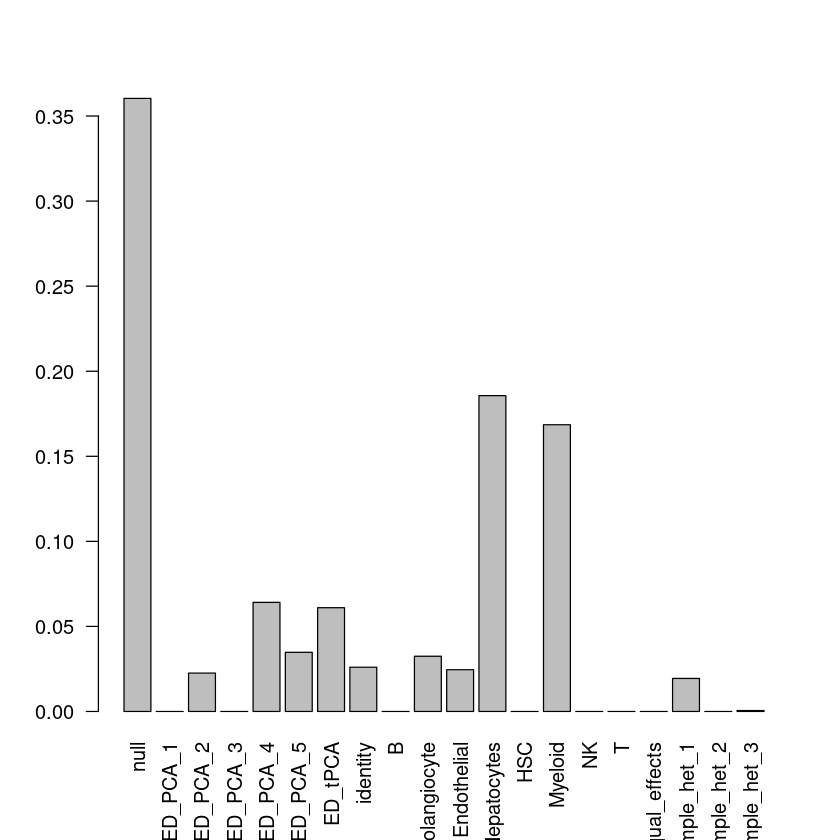

In [44]:
barplot(get_estimated_pi(m2),las = 2)

In [45]:
print(get_pairwise_sharing(m2, factor=0))

              B Cholangiocyte Endothelial Hepatocytes       HSC   Myeloid NK
B             1     1.0000000   1.0000000   1.0000000 1.0000000 1.0000000  1
Cholangiocyte 1     1.0000000   1.0000000   0.9588689 1.0000000 1.0000000  1
Endothelial   1     1.0000000   1.0000000   0.9588689 1.0000000 1.0000000  1
Hepatocytes   1     0.9588689   0.9588689   1.0000000 0.9922879 0.9280206  1
HSC           1     1.0000000   1.0000000   0.9922879 1.0000000 1.0000000  1
Myeloid       1     1.0000000   1.0000000   0.9280206 1.0000000 1.0000000  1
NK            1     1.0000000   1.0000000   1.0000000 1.0000000 1.0000000  1
T             1     1.0000000   1.0000000   0.9897172 1.0000000 1.0000000  1
                      T
B             1.0000000
Cholangiocyte 1.0000000
Endothelial   1.0000000
Hepatocytes   0.9897172
HSC           1.0000000
Myeloid       1.0000000
NK            1.0000000
T             1.0000000


In [46]:
data.frame(matrix(as.numeric(get_lfsr(m2) < .01), ncol=8))

X1,X2,X3,X4,X5,X6,X7,X8
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
0,0,0,1,0,0,0,0
1,1,1,1,1,1,1,1
0,0,0,1,0,0,0,0
0,0,0,1,0,0,0,0
1,1,1,1,1,1,1,1


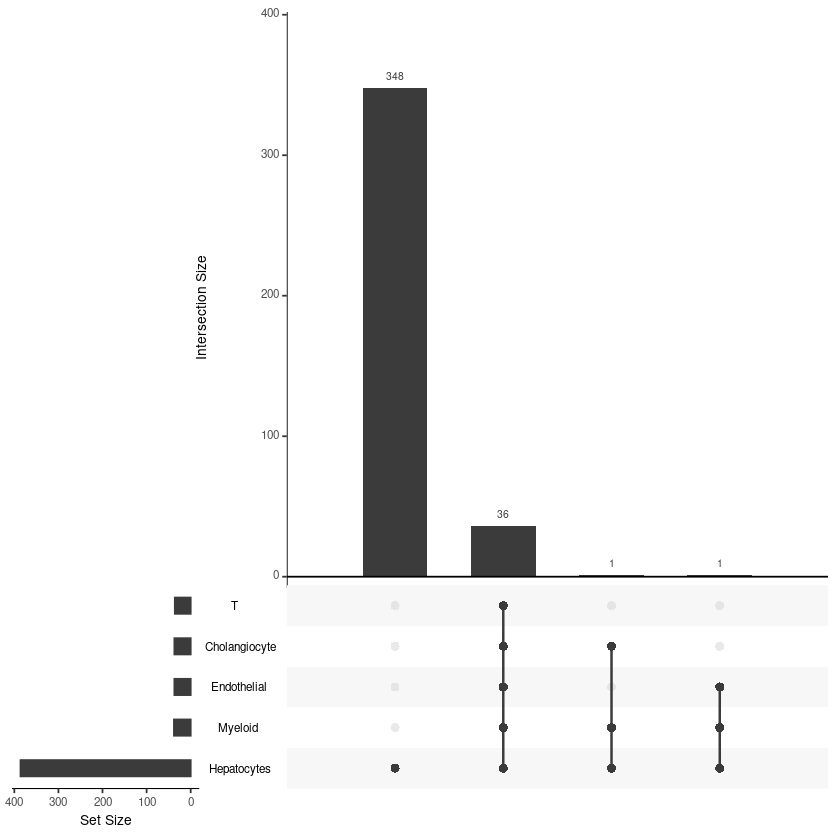

In [47]:
library(UpSetR)

upset_data <- data.frame(matrix(as.numeric(get_lfsr(m2) < .01), ncol=8))
colnames(upset_data) <- colnames(get_lfsr(m2))

upset(upset_data, order.by = "freq")

In [2]:
out.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/mashr/'
lfsr <- read.table(paste0(out.dir, '241125_WE_lead_lfsr.tsv'), sep='\t', header=T)
dim(lfsr)
head(lfsr)

library(UpSetR)

pdf('/nfs/lab/welison/Liver/Plots/241213_WE_H3K27me3_QTL_Specificifty_Upset.pdf', height=6, width=10)

upset_data <- data.frame(matrix(as.numeric(lfsr < .01), ncol=8))
colnames(upset_data) <- colnames(lfsr)

upset(upset_data, order.by = "freq", text.scale = 2, nintersects=15)

dev.off()

[1] 391   8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:113502353-113503852:rs77637430,1.126413e-04,1.520821e-06,4.173494e-07,1.514344e-12,1.896359e-03,1.781018e-05,4.272658e-04,8.307225e-05
chr5:178584897-178586396:rs540371,2.699431e-10,0.000000e+00,8.659740e-15,0.000000e+00,1.728506e-12,1.110223e-16,3.529305e-06,2.738511e-10
chr5:178584897-178586396:rs262042,4.391025e-09,0.000000e+00,2.614575e-13,0.000000e+00,1.948330e-12,8.437695e-15,6.312273e-06,1.484939e-09
chr14:105161822-105163321:rs2280797,6.110699e-04,5.106511e-04,1.026158e-05,2.136206e-26,1.596019e-04,2.072571e-09,1.005556e-03,5.048537e-05
chr1:11393161-11394660:rs55990971,9.982714e-01,9.983743e-01,9.983672e-01,6.045298e-05,9.982545e-01,9.979859e-01,9.982874e-01,9.982664e-01
chr1:152600968-152602467:rs6677595,1.250564e-04,4.697682e-05,1.250563e-04,0.000000e+00,1.250563e-04,1.250563e-04,1.250568e-04,1.250564e-04


png 
  2